In [202]:
import scipy.io
from scipy.stats import ks_2samp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, precision_score, recall_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 11,
    "font.size": 11,
    "figure.dpi": 120,
})

mat_path = '../datasets/archetypometricsdata2000.mat'

N_TRAITS = 360   # number of trait dimensions to use (max 464)

In [203]:
mat = scipy.io.loadmat(str(mat_path), simplify_cells=True)

archetype_space = mat["data_raw"]["A"]  # (464, 2000)
trait_names_raw = mat["data_traits"]["trait_typenames"]                     # (464,)

def sanitize(name):
    return name.replace(' :: ', '__').replace(' ', '_').replace('-', '_')

trait_names = [sanitize(n) for n in trait_names_raw[:N_TRAITS]]
print(f"Using {N_TRAITS} of {archetype_space.shape[0]} available trait dimensions")
print(f"Sample trait names: {trait_names[:5]}")

ds = mat["data_stories"]
story_names_arr = ds["storyverses"]
story_char_idx  = ds["storycharacterindices"]
story_index = {
    story_names_arr[i]: (story_char_idx[i] - 1)
    for i in range(len(story_names_arr))
}

story_imdb = pd.read_csv('../prepared_data/story_imdb_mapping.csv')
genres    = story_imdb.groupby("story_name")["imdb_genres"].first().fillna("")
is_comedy = genres.str.contains("Comedy")
is_drama  = genres.str.contains("Drama")
pure      = is_comedy ^ is_drama
genre_labels = is_comedy[pure].astype(int)

# hl = pd.read_csv('../prepared_data/hand_labels.csv')
# hl = hl.dropna(subset=["label"])
# hl = hl[hl["label"].astype(str).str.strip().isin(["0", "1", "0.0", "1.0"])]
# hl["label"] = hl["label"].astype(float).astype(int)
# hl = hl.set_index("story_name")["label"]
# genre_labels = hl.combine_first(genre_labels).astype(int)

print(f"\nLabeled stories: {len(genre_labels)}  (comedy={genre_labels.sum()}, drama={(genre_labels==0).sum()})")

Using 360 of 464 available trait dimensions
Sample trait names: ['playful__serious', 'shy__bold', 'cheery__sorrowful', 'masculine__feminine', 'charming__awkward']

Labeled stories: 203  (comedy=65, drama=138)


In [204]:
def radius_gyration(A):
    centroid = np.mean(A, axis=1, keepdims=True)
    differences = A - centroid
    squared_distances = np.sum(differences ** 2, axis=0)
    return np.sqrt(np.mean(squared_distances))

rows = []
for story_name, is_comedy_val in genre_labels.items():
    if story_name not in story_index:
        continue

    char_idx = np.atleast_1d(story_index[story_name])
    scores   = archetype_space[:N_TRAITS, char_idx]  # (N_TRAITS, n_chars)

    n_chars = len(char_idx)
    row = {"story_name": story_name, "is_comedy": int(is_comedy_val), "cast_size": n_chars}

    for j, trait in enumerate(trait_names):
        row[f"{trait}_mean"] = scores[j].mean()

    row["cast_gyration"] = radius_gyration(scores)
    rows.append(row)

df = pd.DataFrame(rows).set_index("story_name")
print(f"Stories: {len(df)},  Columns: {df.shape[1]}  ({N_TRAITS} trait means + cast_size + cast_gyration + is_comedy)")
df.head(3)

Stories: 203,  Columns: 363  (360 trait means + cast_size + cast_gyration + is_comedy)


,is_comedy,cast_size,playful__serious_mean,shy__bold_mean,cheery__sorrowful_mean,masculine__feminine_mean,charming__awkward_mean,lewd__tasteful_mean,intellectual__physical_mean,strict__lenient_mean,...,monotone__expressive_mean,love_focused__money_focused_mean,transparent__machiavellian_mean,timid__cocky_mean,concise__long_winded_mean,picky__always_down_mean,proactive__reactive_mean,prudish__flirtatious_mean,innocent__jaded_mean,cast_gyration
story_name,,,,,,,,,,,,,,,,,,,,,
8 Mile,0,1,0.221000,0.231000,0.2240,-0.349000,-0.026000,-0.0890,-0.072,0.094,...,0.183000,0.015000,0.044000,0.125000,-0.083000,0.0690,0.122000,0.215000,0.199000,0.000000
A Series of Unfortunate Events,1,3,0.181333,0.162333,0.2080,-0.019667,0.040667,0.0930,-0.282,-0.177,...,0.090333,-0.021667,0.099667,0.031333,0.038333,-0.1050,-0.000667,-0.160667,0.107667,3.981283
A Star Is Born,0,2,-0.027000,0.151500,0.1185,-0.039000,-0.160000,0.1075,0.019,0.161,...,0.136000,-0.199500,0.041500,0.045000,-0.039500,0.1315,0.108500,0.212000,0.179500,1.967183


In [205]:
comedy = df[df['is_comedy'] == 1]
drama  = df[df['is_comedy'] == 0]

feature_cols = [c for c in df.columns if c != 'is_comedy']
results = []
for col in feature_cols:
    stat, pval = ks_2samp(comedy[col].values, drama[col].values)
    results.append({'feature': col, 'ks_stat': stat, 'p_value': pval})

ks_df = (pd.DataFrame(results)
           .sort_values('ks_stat', ascending=False)
           .reset_index(drop=True))
ks_df['significant'] = ks_df['p_value'] < 0.05

print(f"Significant features (p < 0.05): {ks_df['significant'].sum()} / {len(ks_df)}")
print("\nTop 20 most discriminating traits:")
ks_df.head(20).round(4)

Significant features (p < 0.05): 193 / 362

Top 20 most discriminating traits:


,feature,ks_stat,p_value,significant
0,comedic__dramatic_mean,0.5517,0.0,True
1,epic__deep_mean,0.5319,0.0,True
2,cheery__sorrowful_mean,0.4957,0.0,True
3,secretive__open_book_mean,0.4957,0.0,True
4,zany__regular_mean,0.4957,0.0,True
5,chatty__reserved_mean,0.4894,0.0,True
6,hypochondriac__stoic_mean,0.4893,0.0,True
7,funny__humorless_mean,0.4893,0.0,True
8,stoic__expressive_mean,0.4794,0.0,True
9,open__guarded_mean,0.4785,0.0,True


In [206]:
target       = 'is_comedy'
all_feat_cols = [c for c in df.columns if c != target]

X_all = df[all_feat_cols].values
y     = df[target].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compare regularization strengths — with 466 features and 247 samples, C matters
results_cv = []
for C in [0.01, 0.1, 1.0]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=2000, C=C, class_weight='balanced'))
    ])
    scores = cross_validate(pipe, X_all, y, cv=cv,
                            scoring=['roc_auc', 'f1', 'accuracy'])
    results_cv.append({
        'C (regularization)': C,
        'AUC':      scores['test_roc_auc'].mean(),
        'AUC_std':  scores['test_roc_auc'].std(),
        'F1':       scores['test_f1'].mean(),
        'F1_std':   scores['test_f1'].std(),
        'Accuracy': scores['test_accuracy'].mean(),
        'Acc_std':  scores['test_accuracy'].std(),
    })

pd.DataFrame(results_cv).round(3)

,C (regularization),AUC,AUC_std,F1,F1_std,Accuracy,Acc_std
0,0.01,0.882,0.058,0.713,0.072,0.803,0.036
1,0.10,0.892,0.068,0.741,0.105,0.832,0.049
2,1.00,0.885,0.065,0.731,0.066,0.823,0.029


In [207]:
# Use C=0.1 (stronger regularization) given high dimensionality
BEST_C = 0.1

np.random.seed(42)
fold_results  = []
all_y_test    = []
all_y_pred    = []
fold_tprs     = []
fold_aucs     = []
fold_precs    = []
fold_aps      = []
mean_fpr      = np.linspace(0, 1, 300)
mean_recall   = np.linspace(0, 1, 300)

for train_idx, test_idx in cv.split(X_all, y):
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y[train_idx],     y[test_idx]

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=2000, C=BEST_C, class_weight='balanced')
    clf.fit(X_tr_sc, y_train)

    y_pred = clf.predict(X_te_sc)
    y_prob = clf.predict_proba(X_te_sc)[:, 1]

    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)

    fold_results.append({
        'AUC':      roc_auc_score(y_test, y_prob),
        'F1':       f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fold_tprs.append(np.interp(mean_fpr, fpr, tpr))
    fold_tprs[-1][0] = 0.0
    fold_aucs.append(auc(fpr, tpr))

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    fold_precs.append(np.interp(mean_recall, recall[::-1], precision[::-1]))
    fold_aps.append(average_precision_score(y_test, y_prob))

print("All-trait model (class_weight='balanced', C=0.1):")
pd.DataFrame(fold_results).describe().loc[['mean', 'std']].round(3)

All-trait model (class_weight='balanced', C=0.1):


,AUC,F1,Accuracy
mean,0.892,0.741,0.832
std,0.076,0.117,0.054


In [208]:
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

cm = confusion_matrix(all_y_test, all_y_pred)
tn, fp, fn, tp = cm.ravel()

print("Pooled confusion matrix (5-fold CV):")
print(f"\n{'':25s} Predicted Comedy  Predicted Drama")
print(f"{'Actual Comedy':25s} {tp:^16d}  {fn:^15d}")
print(f"{'Actual Drama':25s} {fp:^16d}  {tn:^15d}")

prec = precision_score(all_y_test, all_y_pred)
rec  = recall_score(all_y_test, all_y_pred)
f1   = f1_score(all_y_test, all_y_pred)
acc  = accuracy_score(all_y_test, all_y_pred)
print(f"\nPrecision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}  Accuracy: {acc:.3f}")

Pooled confusion matrix (5-fold CV):

                          Predicted Comedy  Predicted Drama
Actual Comedy                    51               14       
Actual Drama                     20               118      

Precision: 0.718  Recall: 0.785  F1: 0.750  Accuracy: 0.833


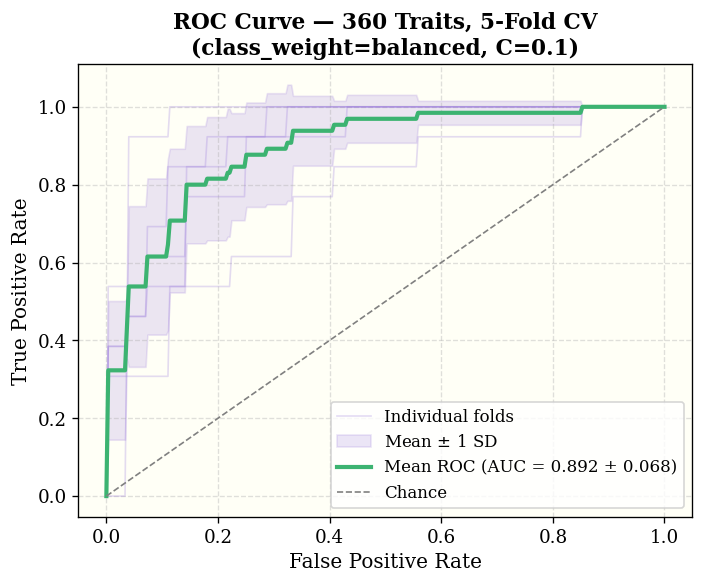

In [209]:
mean_tpr      = np.mean(fold_tprs, axis=0)
mean_tpr[-1]  = 1.0
std_tpr       = np.std(fold_tprs, axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor((1.0, 1.0, 0.965))

for i, tpr_fold in enumerate(fold_tprs):
    ax.plot(mean_fpr, tpr_fold, color='mediumpurple', alpha=0.25, linewidth=1,
            label='Individual folds' if i == 0 else None)

ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                color='mediumpurple', alpha=0.18, label=r'Mean $\pm$ 1 SD')
ax.plot(mean_fpr, mean_tpr, color='mediumseagreen', linewidth=2.5,
        label=f'Mean ROC (AUC = {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Chance')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve — {N_TRAITS} Traits, 5-Fold CV\n(class_weight=balanced, C={BEST_C})', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../figures/genre_prediction_roc_all_traits.png', dpi=300)
plt.show()

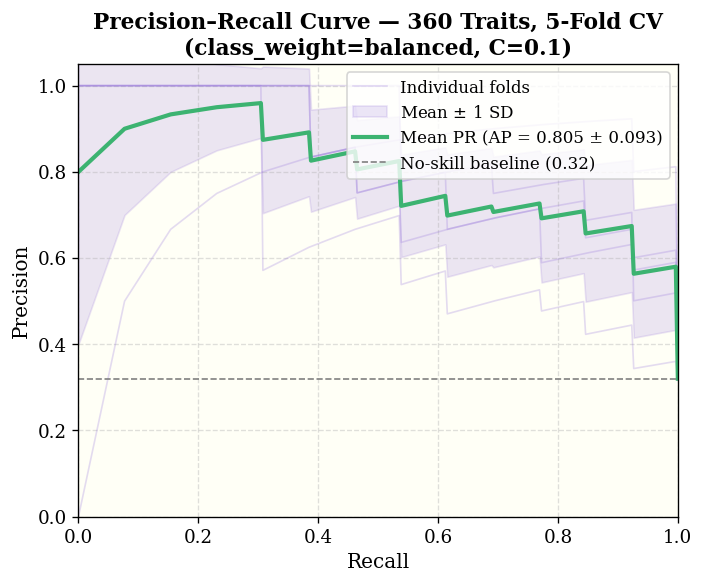

In [210]:
mean_precision      = np.mean(fold_precs, axis=0)
std_precision       = np.std(fold_precs, axis=0)
baseline_precision  = y.mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor((1.0, 1.0, 0.965))

for i, prec_fold in enumerate(fold_precs):
    ax.plot(mean_recall, prec_fold, color='mediumpurple', alpha=0.25, linewidth=1,
            label='Individual folds' if i == 0 else None)

ax.fill_between(mean_recall, mean_precision - std_precision, mean_precision + std_precision,
                color='mediumpurple', alpha=0.18, label=r'Mean $\pm$ 1 SD')
ax.plot(mean_recall, mean_precision, color='mediumseagreen', linewidth=2.5,
        label=f'Mean PR (AP = {np.mean(fold_aps):.3f} ± {np.std(fold_aps):.3f})')
ax.axhline(baseline_precision, linestyle='--', color='gray', linewidth=1,
           label=f'No-skill baseline ({baseline_precision:.2f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(f'Precision–Recall Curve — {N_TRAITS} Traits, 5-Fold CV\n(class_weight=balanced, C={BEST_C})', fontsize=13, fontweight='bold')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../figures/genre_prediction_pr_all_traits.png', dpi=300)
plt.show()

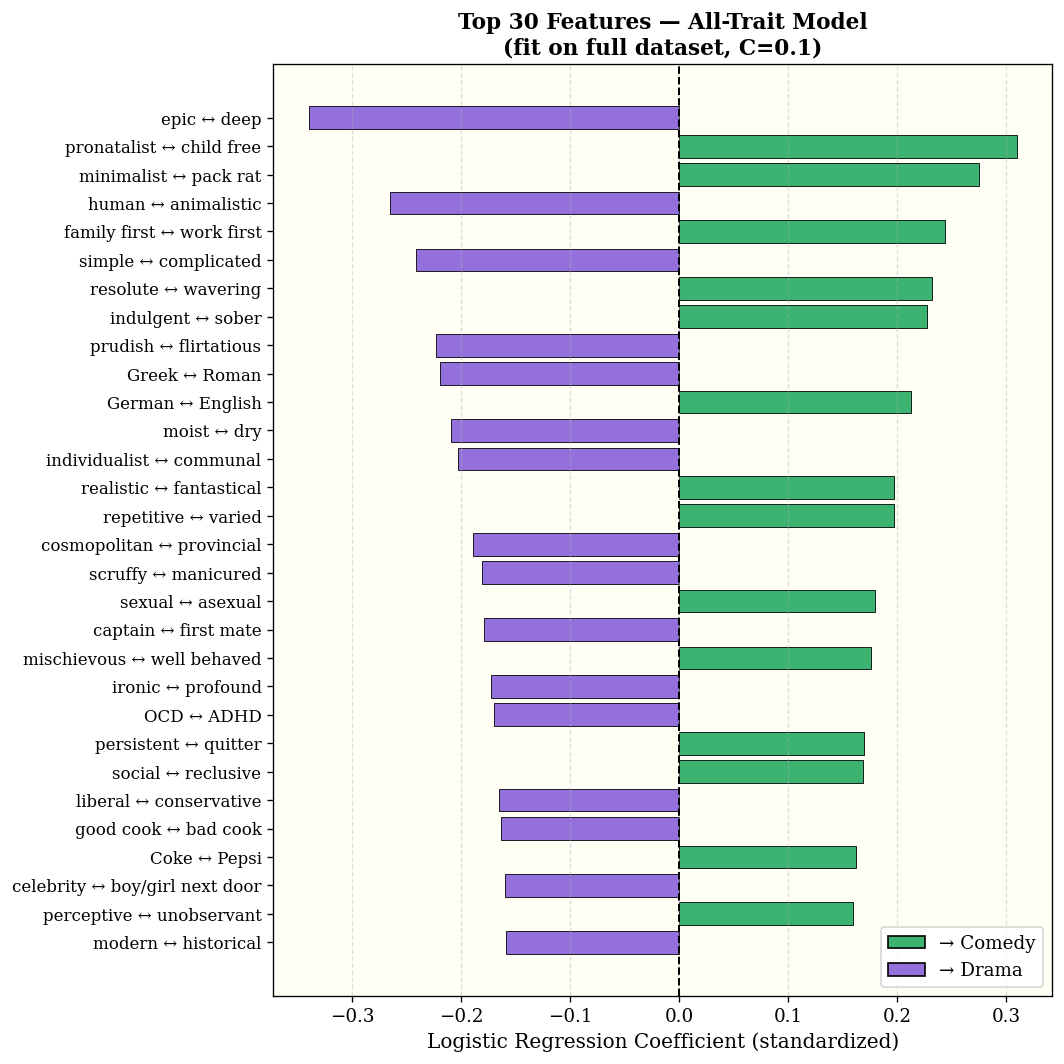

In [211]:
# Top 30 traits by coefficient magnitude (fit on full dataset)
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_all)
clf_full = LogisticRegression(max_iter=2000, C=BEST_C, class_weight='balanced')
clf_full.fit(X_scaled_full, y)

coefs  = clf_full.coef_[0]
labels = [c.replace('_mean', '').replace('__', ' ↔ ').replace('_', ' ') for c in all_feat_cols]

top_n  = 30
order  = np.argsort(np.abs(coefs))[-top_n:]
coefs_sorted  = coefs[order]
labels_sorted = [labels[i] for i in order]
colors = ['mediumseagreen' if c > 0 else 'mediumpurple' for c in coefs_sorted]

fig, ax = plt.subplots(figsize=(9, 9))
ax.set_facecolor((1.0, 1.0, 0.965))
ax.barh(range(top_n), coefs_sorted, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(labels_sorted, fontsize=10)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel("Logistic Regression Coefficient (standardized)", fontsize=12)
ax.set_title(
    f"Top {top_n} Features — All-Trait Model\n(fit on full dataset, C={BEST_C})",
    fontsize=13, fontweight='bold'
)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

comedy_patch = mpatches.Patch(facecolor='mediumseagreen', edgecolor='black', label='→ Comedy')
drama_patch  = mpatches.Patch(facecolor='mediumpurple',   edgecolor='black', label='→ Drama')
ax.legend(handles=[comedy_patch, drama_patch], fontsize=11, loc='lower right')

plt.tight_layout()
plt.savefig('../figures/logistic_coef_all_traits.png', dpi=300)
plt.show()

n=   6  AUC=0.850 ± 0.056  F1=0.673 ± 0.088
n=  10  AUC=0.849 ± 0.060  F1=0.666 ± 0.096
n=  20  AUC=0.831 ± 0.058  F1=0.676 ± 0.083
n=  30  AUC=0.828 ± 0.062  F1=0.686 ± 0.090
n=  50  AUC=0.836 ± 0.071  F1=0.681 ± 0.097
n=  75  AUC=0.816 ± 0.080  F1=0.655 ± 0.075
n= 100  AUC=0.825 ± 0.079  F1=0.647 ± 0.089
n= 150  AUC=0.850 ± 0.070  F1=0.676 ± 0.100
n= 200  AUC=0.871 ± 0.065  F1=0.706 ± 0.095
n= 300  AUC=0.893 ± 0.072  F1=0.716 ± 0.110
n= 400  AUC=0.885 ± 0.068  F1=0.747 ± 0.112
n= 464  AUC=0.881 ± 0.077  F1=0.738 ± 0.110


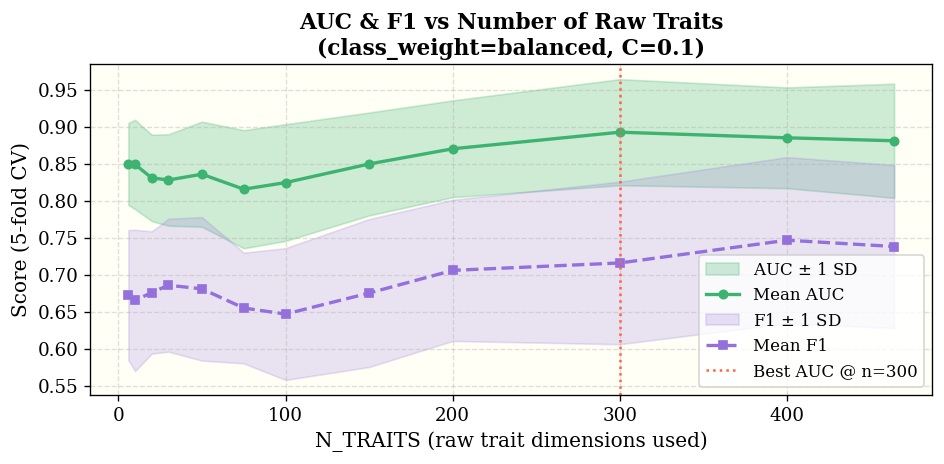


Best AUC: 0.893 at N_TRAITS=300


In [212]:
trait_counts  = [6, 10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 464]
sweep_results = []

for n in trait_counts:
    trait_names_n = [sanitize(t) for t in trait_names_raw[:n]]
    rows_n = []
    for story_name, is_comedy_val in genre_labels.items():
        if story_name not in story_index:
            continue
        char_idx = np.atleast_1d(story_index[story_name])
        scores   = mat["data_raw"]["A"][:n, char_idx]
        row = {"is_comedy": int(is_comedy_val), "cast_size": len(char_idx)}
        for j, trait in enumerate(trait_names_n):
            row[f"{trait}_mean"] = scores[j].mean()
        row["cast_gyration"] = radius_gyration(scores)
        rows_n.append(row)

    df_n  = pd.DataFrame(rows_n)
    X_n   = df_n.drop(columns="is_comedy").values
    y_n   = df_n["is_comedy"].values

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=2000, C=BEST_C, class_weight="balanced")),
    ])
    s = cross_validate(pipe, X_n, y_n, cv=cv, scoring=["roc_auc", "f1"])
    sweep_results.append({
        "n_traits": n,
        "auc_mean": s["test_roc_auc"].mean(),
        "auc_std":  s["test_roc_auc"].std(),
        "f1_mean":  s["test_f1"].mean(),
        "f1_std":   s["test_f1"].std(),
    })
    print(f"n={n:4d}  AUC={s['test_roc_auc'].mean():.3f} \u00b1 {s['test_roc_auc'].std():.3f}"
          f"  F1={s['test_f1'].mean():.3f} \u00b1 {s['test_f1'].std():.3f}")

sweep_df = pd.DataFrame(sweep_results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.set_facecolor((1.0, 1.0, 0.965))

ax.fill_between(sweep_df["n_traits"],
                sweep_df["auc_mean"] - sweep_df["auc_std"],
                sweep_df["auc_mean"] + sweep_df["auc_std"],
                alpha=0.25, color="mediumseagreen", label=r"AUC $\pm$ 1 SD")
ax.plot(sweep_df["n_traits"], sweep_df["auc_mean"],
        color="mediumseagreen", linewidth=2, marker="o", markersize=5, label="Mean AUC")

ax.fill_between(sweep_df["n_traits"],
                sweep_df["f1_mean"] - sweep_df["f1_std"],
                sweep_df["f1_mean"] + sweep_df["f1_std"],
                alpha=0.2, color="mediumpurple", label=r"F1 $\pm$ 1 SD")
ax.plot(sweep_df["n_traits"], sweep_df["f1_mean"],
        color="mediumpurple", linewidth=2, marker="s", markersize=5,
        linestyle="--", label="Mean F1")

best_idx = sweep_df["auc_mean"].idxmax()
best_n   = sweep_df.loc[best_idx, "n_traits"]
best_auc = sweep_df.loc[best_idx, "auc_mean"]
ax.axvline(best_n, color="tomato", linestyle=":", linewidth=1.5,
           label=f"Best AUC @ n={best_n}")

ax.set_xlabel("N_TRAITS (raw trait dimensions used)", fontsize=12)
ax.set_ylabel("Score (5-fold CV)", fontsize=12)
ax.set_title(f"AUC & F1 vs Number of Raw Traits\n(class_weight=balanced, C={BEST_C})",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/auc_vs_n_traits.png", dpi=300)
plt.show()

print(f"\nBest AUC: {best_auc:.3f} at N_TRAITS={best_n}")